# **MNIST BM - Measures of Quality**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models
import sys, os
sys.path.append(os.getcwd())

/content/drive/MyDrive/proyecto_AAIII_02_diffusion_models


In [3]:
!pip install torchmetrics
!pip install torch-fidelity

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 5.0 MB/s eta 0:00:00


## Imports

In [4]:
import os
import sys

import torch
import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import Subset
from torchvision import datasets
from torchvision.transforms import ToTensor, Normalize, Resize, Compose

from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore

PROJECT_ROOT = "/content/drive/MyDrive/proyecto_AAIII_02_diffusion_models"
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)

from src.metrics import (
    to_01_range,
    inception_uint8,
    load_saved_samples,
    bpd_probability_flow_ode,
)

from src.score_model import ScoreNet
from src.brownian import (
    make_bm_process_functions,
    make_bm_probability_flow_drift,
)

## Basic configuration

In [5]:
if torch.cuda.is_available():
    device_str = "cuda"
elif torch.backends.mps.is_available():
    device_str = "mps"
else:
    device_str = "cpu"

device = torch.device(device_str)
print("Device:", device)

n_threads = torch.get_num_threads()
print("Number of threads:", n_threads)

_ = torch.manual_seed(123)

Device: cuda
Number of threads: 6


## Load Dataset

In [6]:
transform = Compose([
    Resize((32, 32)),
    ToTensor(),
    Normalize((0.5,), (0.5,))
])

data = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

digit = 3
indices_digit = torch.where(data.targets == digit)[0]
data_train = Subset(data, indices_digit)

print(type(data_train))
print("Number of images:", len(data_train))

<class 'torch.utils.data.dataset.Subset'>
Number of images: 6131


## Measure models and samplers

In [7]:
epochs = [10, 20, 50, 100, 200, 500]
sampler_keys = ["final_images_em", "final_images_ode", "final_images_pc"]

sampler_names = {
    "final_images_em": "em",
    "final_images_ode": "ode",
    "final_images_pc": "pc",
}

sigma = 25.0
bm_sched = make_bm_process_functions(sigma)

# BPD configuration
n_bpd_images = min(2000, len(data_train))
bpd_batch_size = 32
bpd_n_steps = 500

results = []

for epoch in epochs:
    sample_file = f"./samples/mnist_bm/final_images_epoch{epoch}.pt"
    checkpoint_path = f"./checkpoints/mnist_bm/checkpoint_mnist_bm_epoch{epoch}.pth"

    if not os.path.exists(sample_file):
        print(f"Skipping mnist_bm epoch {epoch}: sample file not found")
        continue

    if not os.path.exists(checkpoint_path):
        print(f"Skipping mnist_bm epoch {epoch}: checkpoint not found")
        continue

    # Load score model for BPD computation
    score_model = ScoreNet(
        marginal_prob_std=bm_sched["sigma_t"],
        in_channels=1,
        out_channels=1,
    ).to(device)

    state_dict = torch.load(checkpoint_path, map_location=device)
    score_model.load_state_dict(state_dict)
    score_model.eval()

    probability_flow_drift = make_bm_probability_flow_drift(
        diffusion_coefficient=bm_sched["diffusion_coefficient"],
        score_model=score_model,
    )

    terminal_std = bm_sched["sigma_t"](
        torch.tensor([1.0], device=device)
    ).item()

    # BPD is computed on real images using the probability flow ODE.
    # It depends on the model/checkpoint, not on the sampler.
    # Uniform dequantization is applied only for likelihood evaluation.
    bpd_values = []

    for start in range(0, n_bpd_images, bpd_batch_size):
        end = min(start + bpd_batch_size, n_bpd_images)

        bpd_images = torch.stack([
            data_train[i][0] for i in range(start, end)
        ]).to(device)

        # Convert from [-1, 1] to [0, 1].
        bpd_images = (bpd_images + 1.0) / 2.0

        # Uniform dequantization.
        bpd_images = (bpd_images * 255.0 + torch.rand_like(bpd_images)) / 256.0

        # Convert back from [0, 1] to [-1, 1].
        bpd_images = bpd_images * 2.0 - 1.0

        _, bpd_batch = bpd_probability_flow_ode(
            x_0=bpd_images,
            probability_flow_drift=probability_flow_drift,
            terminal_std=terminal_std,
            t_0=1.0e-3,
            t_end=1.0,
            n_steps=bpd_n_steps,
        )

        bpd_values.append(bpd_batch.detach().cpu())

    # Raw BPD is computed in the normalized [-1, 1] domain.
    # Add the 8-bit dequantization/change-of-variables correction:
    # x_uint8 -> [0,1] -> [-1,1].
    bpd_value = torch.cat(bpd_values).mean().item() + 7.0

    for sampler_key in sampler_keys:
        generated_images = load_saved_samples(
            sample_file,
            sampler_key=sampler_key,
        )

        generated_images_01 = to_01_range(
            generated_images,
            assume_minus1_1=True,
        )

        target_n = generated_images_01.shape[0]

        real_images = torch.stack([
            data_train[i][0] for i in range(target_n)
        ])

        real_images_01 = to_01_range(
            real_images,
            assume_minus1_1=True,
        )

        real_u8 = inception_uint8(real_images_01).to(device)
        generated_u8 = inception_uint8(generated_images_01).to(device)

        fid_metric = FrechetInceptionDistance(
            feature=2048,
            normalize=False,
        ).to(device)

        fid_metric.update(real_u8, real=True)
        fid_metric.update(generated_u8, real=False)
        fid_value = fid_metric.compute().item()

        is_metric = InceptionScore(normalize=False).to(device)
        is_metric.update(generated_u8)
        is_mean, is_std = is_metric.compute()

        results.append({
            "epoch": epoch,
            "sampler": sampler_names[sampler_key],
            "fid": round(fid_value, 4),
            "is_mean": round(is_mean.item(), 4),
            "is_std": round(is_std.item(), 4),
            "bpd_ode": round(bpd_value, 4),
        })

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:01<00:00, 74.8MB/s]
/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


## Show result

In [8]:
results_df = pd.DataFrame(results)
display(results_df.sort_values(["fid", "epoch"]))

,epoch,sampler,fid,is_mean,is_std,bpd_ode
4,20,ode,100.1155,1.7954,0.0424,3.2185
8,50,pc,102.7401,1.5061,0.0257,2.7920
9,100,em,106.6118,1.7000,0.0274,2.7436
11,100,pc,106.6496,1.7294,0.0362,2.7436
13,200,ode,108.0395,1.6020,0.0258,2.7924
14,200,pc,112.5254,1.6507,0.0333,2.7924
12,200,em,112.7765,1.6400,0.0389,2.7924
10,100,ode,116.4401,1.6547,0.0515,2.7436
6,50,em,118.1202,1.6007,0.0374,2.7920
16,500,ode,119.1333,1.4521,0.0394,2.6897


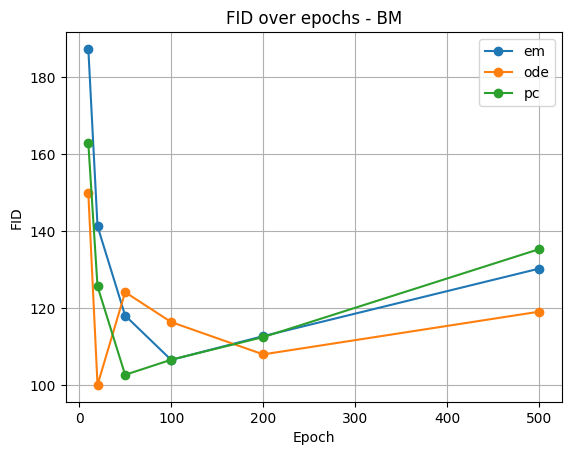

In [9]:
for sampler in ["em", "ode", "pc"]:
    subset = results_df[results_df["sampler"] == sampler]
    plt.plot(subset["epoch"], subset["fid"], marker="o", label=sampler)

plt.xlabel("Epoch")
plt.ylabel("FID")
plt.title("FID over epochs - BM")
plt.legend()
plt.grid(True)
plt.show()

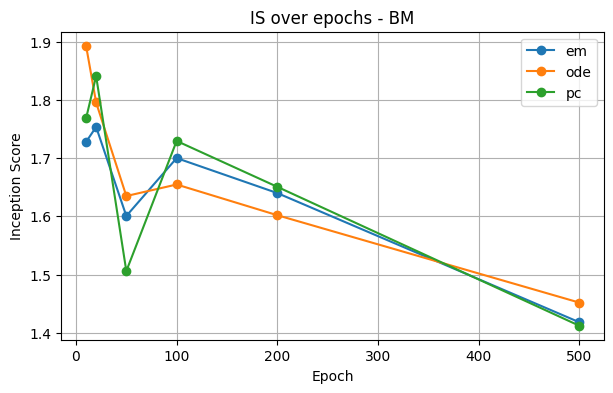

In [10]:
plt.figure(figsize=(7, 4))

for sampler in ["em", "ode", "pc"]:
    subset = results_df[results_df["sampler"] == sampler]
    plt.plot(subset["epoch"], subset["is_mean"], marker="o", label=sampler)

plt.xlabel("Epoch")
plt.ylabel("Inception Score")
plt.title("IS over epochs - BM")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
bpd_summary = (
    results_df[["epoch", "bpd_ode"]]
    .drop_duplicates()
    .sort_values("epoch")
)

display(bpd_summary)

,epoch,bpd_ode
0,10,3.0270
3,20,3.2185
6,50,2.7920
9,100,2.7436
12,200,2.7924
15,500,2.6897


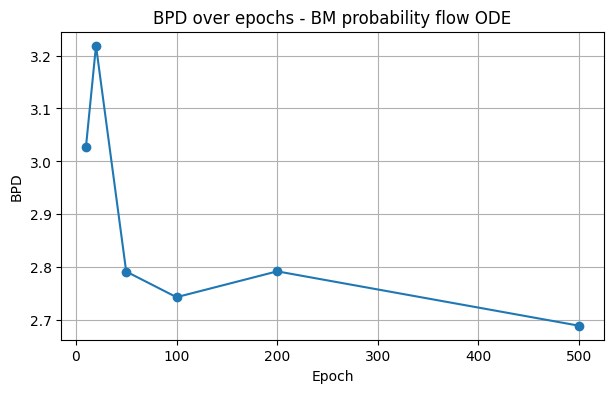

In [12]:
plt.figure(figsize=(7, 4))

plt.plot(
    bpd_summary["epoch"],
    bpd_summary["bpd_ode"],
    marker="o",
)

plt.xlabel("Epoch")
plt.ylabel("BPD")
plt.title("BPD over epochs - BM probability flow ODE")
plt.grid(True)
plt.show()